# Module 02 Notes — VIX Calibration vs. Realized S&P 500 Volatility

This notebook investigates a question that emerged while studying Module 02 of the
**Stock Markets Analytics Zoomcamp**:

> How closely does the VIX — the market's 30-day implied-volatility index for the
> S&P 500 — match the volatility that is subsequently realized?

The analysis progresses from visualization to honest out-of-sample validation:

1. Download and align VIX and S&P 500 data.
2. Construct forward realized-volatility targets.
3. Compare expectation and subsequent realization visually.
4. Reproduce the fixed and adaptive bias-calibration experiment.
5. Test robustness by year and without 2020.
6. Compare against a naive trailing-volatility forecast.
7. Fit a supervised Ridge regression using only information available at forecast time.

The target is continuous, so the ML experiment is a **regression** problem, not a
classification problem. This is an educational analysis, not trading advice.

## 1. Setup

The notebook requires `yfinance`, `pandas`, `numpy`, `matplotlib`, and
`scikit-learn`. The VIX is quoted in annualized percentage points, so every realized-
volatility series below is also annualized and multiplied by 100.

In [2]:
# Uncomment if the environment does not already contain these packages.
# %pip install -q yfinance pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

HORIZON = 21          # Approximately 30 calendar days
ANNUALIZATION = 252   # Trading sessions per year
ANALYSIS_START = "2018-01-01"
TEST_START = "2023-01-01"
BIAS_WINDOW = 252

## 2. Download and align market data

- `^GSPC`: S&P 500 index.
- `^VIX`: CBOE Volatility Index.

Timezone information is removed so both time series can be joined safely.

In [3]:
def get_close(ticker: str, start: str = "1990-01-01") -> pd.Series:
    series = yf.Ticker(ticker).history(
        start=start,
        interval="1d",
        auto_adjust=False,
        actions=False,
    )["Close"].rename(ticker)

    series.index = pd.to_datetime(series.index).tz_localize(None)
    return series


sp500 = get_close("^GSPC").rename("SP500")
vix = get_close("^VIX").rename("VIX_expected")

market = pd.concat([sp500, vix], axis=1).dropna()
log_returns = np.log(market["SP500"]).diff()

print(f"Available period: {market.index.min().date()} to {market.index.max().date()}")
display(market.head())

Available period: 1990-01-02 to 2026-09-17


,SP500,VIX_expected
Date,,
1990-01-02,359.690,17.240
1990-01-03,358.760,18.190
1990-01-04,355.670,19.220
1990-01-05,352.200,20.110
1990-01-08,353.790,20.260


## 3. Construct forward realized-volatility targets

Two definitions are retained.

### 3.1 Initial course-note proxy

The first experiment used the forward standard deviation of the next 21 daily log
returns:

$$
\sigma_{t,t+21}
= \operatorname{std}(r_{t+1},\ldots,r_{t+21})\sqrt{252}.
$$

### 3.2 Variance-based realized volatility

A definition closer to the variance represented by the VIX is:

$$
RV_{t,t+21}
= \sqrt{\frac{252}{21}\sum_{i=1}^{21}r_{t+i}^{2}}.
$$

This second definition uses realized variance and does not subtract the sample mean
of the returns. A trailing version is also created as a naive forecast known at time
$t$.

In [4]:
# Initial proxy used in the exploratory analysis
future_std_vol = (
    log_returns
    .rolling(HORIZON)
    .std()
    .shift(-HORIZON)
    * np.sqrt(ANNUALIZATION)
    * 100
).rename("Future_std_vol")

# Preferred forward realized-volatility target
future_realized_vol = (
    np.sqrt(
        log_returns.pow(2)
        .rolling(HORIZON)
        .mean()
        .shift(-HORIZON)
        * ANNUALIZATION
    )
    * 100
).rename("Future_realized_vol")

# Naive forecast available at time t
trailing_realized_vol = (
    np.sqrt(
        log_returns.pow(2)
        .rolling(HORIZON)
        .mean()
        * ANNUALIZATION
    )
    * 100
).rename("Trailing_realized_vol")

data = pd.concat(
    [
        market,
        log_returns.rename("SP500_log_return"),
        future_std_vol,
        future_realized_vol,
        trailing_realized_vol,
    ],
    axis=1,
)

display(data.loc[ANALYSIS_START:].head())

,SP500,VIX_expected,SP500_log_return,Future_std_vol,Future_realized_vol,Trailing_realized_vol
Date,,,,,,
2018-01-02,"2,695.810",9.770,0.008,8.719,9.185,6.116
2018-01-03,"2,713.060",9.150,0.006,11.808,11.603,6.465
2018-01-04,"2,723.990",9.220,0.004,18.848,18.514,6.603
2018-01-05,"2,743.150",9.220,0.007,19.736,19.307,6.914
2018-01-08,"2,747.710",9.520,0.002,19.765,19.376,6.938


## 4. Visual comparison: expectation versus realization

Each future realized-volatility value is placed at the date on which the corresponding
VIX forecast was observed. Therefore, the orange curve contains the outcome from the
**following** 21 sessions aligned to its forecast origin; it is not itself a real-time
predictor.

- Green: VIX overestimated subsequent volatility.
- Red: VIX underestimated subsequent volatility.

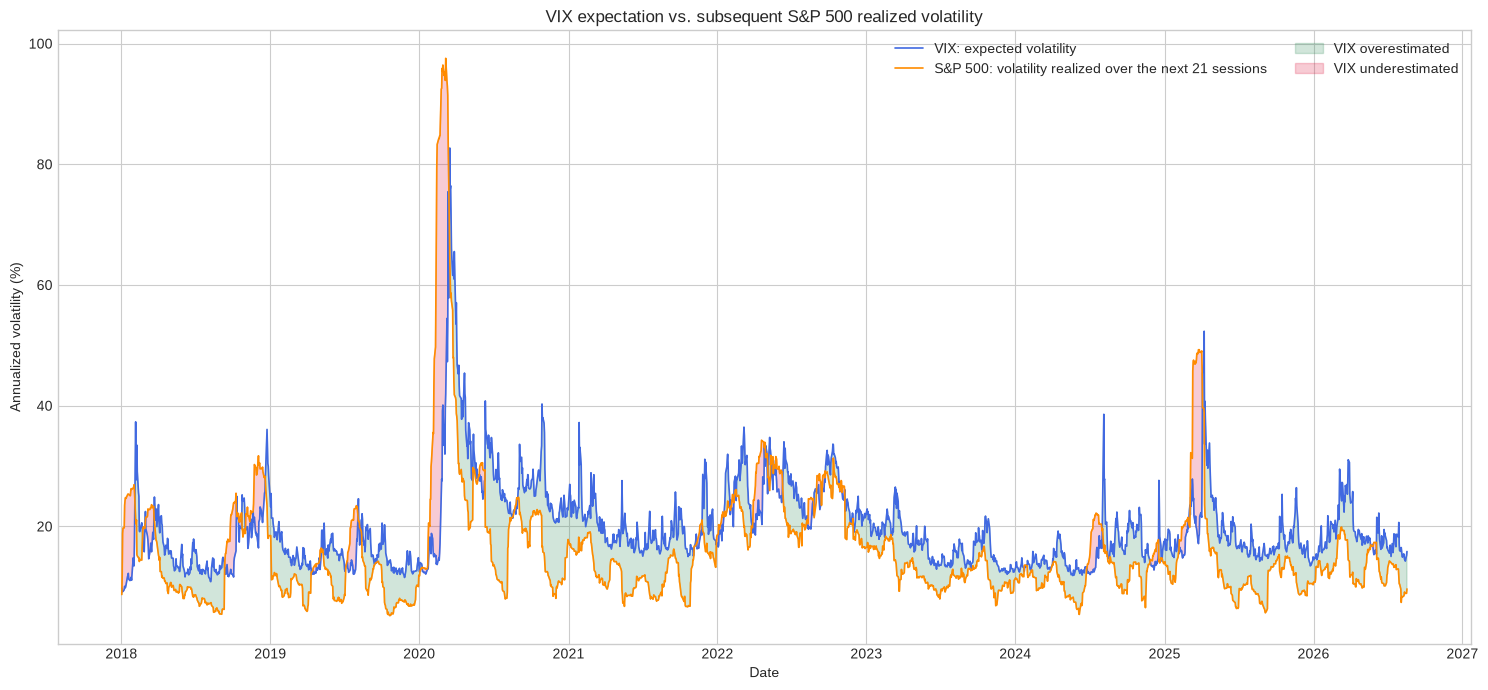

In [5]:
plot_data = data.loc[ANALYSIS_START:].dropna(
    subset=["VIX_expected", "Future_std_vol"]
).copy()

expected = plot_data["VIX_expected"]
realized = plot_data["Future_std_vol"]

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    plot_data.index,
    expected,
    color="royalblue",
    linewidth=1.2,
    label="VIX: expected volatility",
)
ax.plot(
    plot_data.index,
    realized,
    color="darkorange",
    linewidth=1.2,
    label="S&P 500: volatility realized over the next 21 sessions",
)

ax.fill_between(
    plot_data.index,
    expected,
    realized,
    where=expected >= realized,
    interpolate=True,
    color="seagreen",
    alpha=0.22,
    label="VIX overestimated",
)
ax.fill_between(
    plot_data.index,
    expected,
    realized,
    where=expected < realized,
    interpolate=True,
    color="crimson",
    alpha=0.22,
    label="VIX underestimated",
)

ax.set(
    title="VIX expectation vs. subsequent S&P 500 realized volatility",
    xlabel="Date",
    ylabel="Annualized volatility (%)",
)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 5. Evaluation metrics

- **Correlation:** similarity in co-movement or silhouette.
- **MAE:** mean absolute distance in annualized volatility points.
- **RMSE:** error metric that penalizes large misses more heavily.
- **Bias:** signed mean error; positive values mean systematic overestimation.
- **Relative area gap:** accumulated absolute distance divided by accumulated realized
  volatility.
- **$R^2$:** performance relative to predicting the test target mean; it may be negative
  for a poor genuine forecast.

A constant bias correction can improve MAE and bias without changing correlation.

In [6]:
def evaluate_forecast(actual: pd.Series, predicted: pd.Series) -> pd.Series:
    aligned = pd.concat(
        [actual.rename("actual"), predicted.rename("predicted")],
        axis=1,
    ).dropna()

    error = aligned["predicted"] - aligned["actual"]

    return pd.Series(
        {
            "Correlation": aligned["predicted"].corr(aligned["actual"]),
            "MAE": error.abs().mean(),
            "RMSE": np.sqrt(error.pow(2).mean()),
            "Bias": error.mean(),
            "Relative area gap": (
                error.abs().sum() / aligned["actual"].abs().sum()
            ),
            "R2": r2_score(aligned["actual"], aligned["predicted"]),
            "Observations": len(aligned),
        }
    )


initial_metrics = evaluate_forecast(
    plot_data["Future_std_vol"],
    plot_data["VIX_expected"],
)

display(initial_metrics.to_frame("Original VIX"))

,Original VIX
Correlation,0.556
MAE,6.653
RMSE,9.593
Bias,3.485
Relative area gap,0.411
R2,0.185
Observations,"2,168.000"


## 6. Saved snapshot of the initial experiment

Using the standard-deviation proxy and data available on **17 September 2026**, the
first out-of-sample experiment produced these results for 2023 through 18 August 2026:

| Model | Correlation | MAE | Bias | Relative area gap |
|---|---:|---:|---:|---:|
| Original VIX | 0.431 | 5.559 | 3.987 | 0.414 |
| Fixed calibration | 0.431 | 3.663 | 0.879 | 0.273 |
| Adaptive calibration | 0.404 | 3.893 | 0.580 | 0.290 |

The fixed calibration subtracted a bias of **3.107 volatility points**, learned using
2018–2022 only. It reduced out-of-sample MAE by approximately **34.1%**. The adaptive
calibration reduced MAE by approximately **30.0%** and removed more bias, but slightly
distorted co-movement.

In [7]:
snapshot_results = pd.DataFrame(
    {
        "Original VIX": [0.431, 5.559, 3.987, 0.414],
        "Fixed calibration": [0.431, 3.663, 0.879, 0.273],
        "Adaptive calibration": [0.404, 3.893, 0.580, 0.290],
    },
    index=["Correlation", "MAE", "Bias", "Relative area gap"],
)

display(snapshot_results)

print(
    "Fixed calibration MAE improvement:",
    f"{1 - 3.663 / 5.559:.1%}",
)
print(
    "Adaptive calibration MAE improvement:",
    f"{1 - 3.893 / 5.559:.1%}",
)

,Original VIX,Fixed calibration,Adaptive calibration
Correlation,0.431,0.431,0.404
MAE,5.559,3.663,3.893
Bias,3.987,0.879,0.580
Relative area gap,0.414,0.273,0.290


Fixed calibration MAE improvement: 34.1%
Adaptive calibration MAE improvement: 30.0%


## 7. Fixed and adaptive bias calibration

The final 21 training origins are purged so their forward target windows cannot overlap
the test boundary.

- **Fixed calibration:** estimate one mean bias before 2023 and keep it frozen.
- **Adaptive calibration:** subtract a rolling estimate based only on forecast errors
  that would already be observable at the current date.

In [8]:
def prepare_calibrations(frame: pd.DataFrame, target_col: str):
    calibrated = frame.loc[ANALYSIS_START:].copy()

    calibrated["Forecast_error"] = (
        calibrated["VIX_expected"] - calibrated[target_col]
    )

    calibrated["Estimated_adaptive_bias"] = (
        calibrated["Forecast_error"]
        .shift(HORIZON)
        .rolling(BIAS_WINDOW, min_periods=63)
        .mean()
    )

    calibrated["Adaptive_calibration"] = (
        calibrated["VIX_expected"]
        - calibrated["Estimated_adaptive_bias"]
    )

    train_candidates = (
        calibrated.loc[calibrated.index < TEST_START]
        .dropna(subset=["Forecast_error"])
    )
    train = train_candidates.iloc[:-HORIZON].copy()
    fixed_bias = train["Forecast_error"].mean()

    test = (
        calibrated.loc[TEST_START:]
        .dropna(
            subset=[
                target_col,
                "VIX_expected",
                "Adaptive_calibration",
            ]
        )
        .copy()
    )
    test["Fixed_calibration"] = test["VIX_expected"] - fixed_bias

    return calibrated, train, test, fixed_bias


legacy_all, legacy_train, legacy_test, legacy_fixed_bias = (
    prepare_calibrations(data, "Future_std_vol")
)

calibration_columns = {
    "Original VIX": "VIX_expected",
    "Fixed calibration": "Fixed_calibration",
    "Adaptive calibration": "Adaptive_calibration",
}

legacy_test_metrics = pd.concat(
    {
        model_name: evaluate_forecast(
            legacy_test["Future_std_vol"],
            legacy_test[column],
        )
        for model_name, column in calibration_columns.items()
    },
    axis=1,
)

print(
    f"Training: {legacy_train.index.min().date()} to "
    f"{legacy_train.index.max().date()}"
)
print(
    f"Testing:  {legacy_test.index.min().date()} to "
    f"{legacy_test.index.max().date()}"
)
print(f"Fixed training bias: {legacy_fixed_bias:.3f} volatility points")
display(legacy_test_metrics.round(3))

Training: 2018-01-02 to 2022-11-30
Testing:  2023-01-03 to 2026-08-18
Fixed training bias: 3.107 volatility points


,Original VIX,Fixed calibration,Adaptive calibration
Correlation,0.431,0.431,0.404
MAE,5.559,3.663,3.893
RMSE,7.044,5.874,6.095
Bias,3.987,0.879,0.580
Relative area gap,0.414,0.273,0.290
R2,-0.286,0.106,0.037
Observations,909.000,909.000,909.000


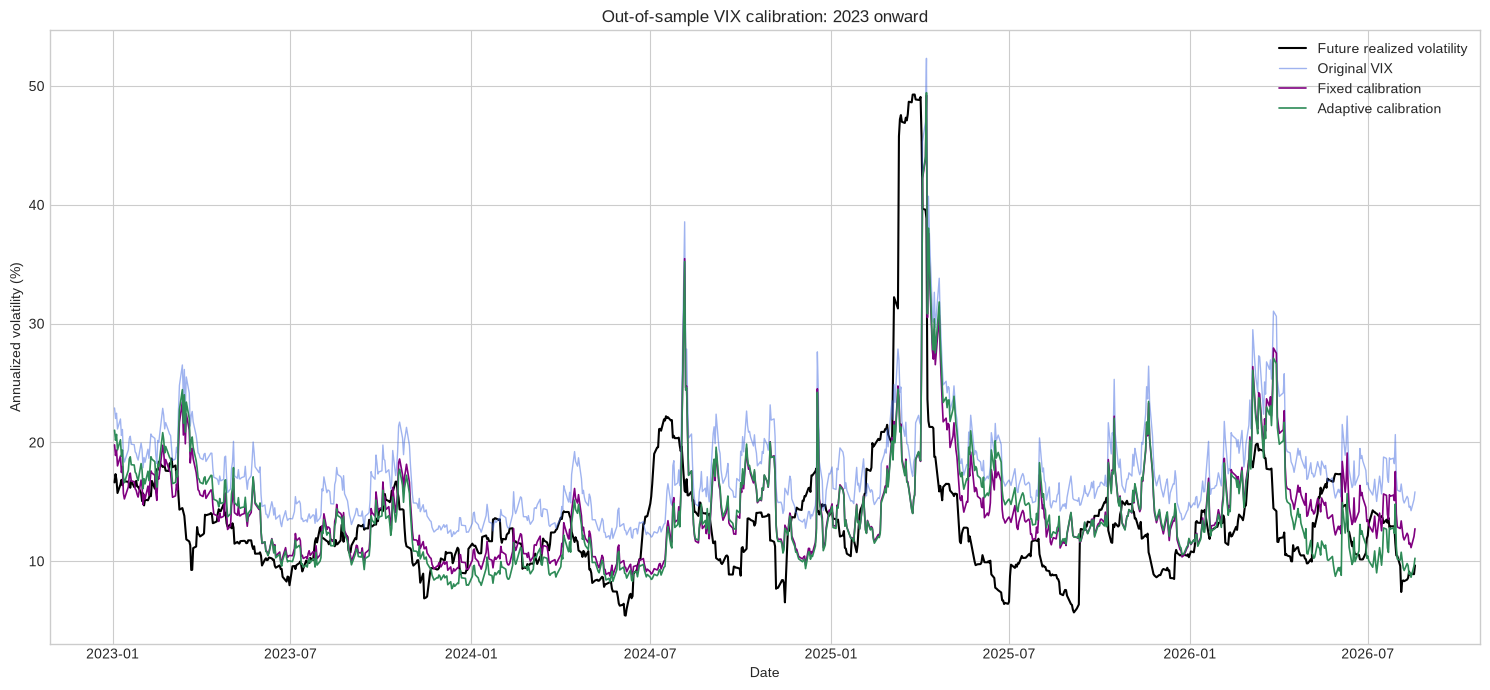

In [9]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    legacy_test.index,
    legacy_test["Future_std_vol"],
    color="black",
    linewidth=1.5,
    label="Future realized volatility",
)
ax.plot(
    legacy_test.index,
    legacy_test["VIX_expected"],
    color="royalblue",
    alpha=0.5,
    linewidth=1.0,
    label="Original VIX",
)
ax.plot(
    legacy_test.index,
    legacy_test["Fixed_calibration"],
    color="purple",
    linewidth=1.2,
    label="Fixed calibration",
)
ax.plot(
    legacy_test.index,
    legacy_test["Adaptive_calibration"],
    color="seagreen",
    linewidth=1.2,
    label="Adaptive calibration",
)

ax.set(
    title="Out-of-sample VIX calibration: 2023 onward",
    xlabel="Date",
    ylabel="Annualized volatility (%)",
)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Annual robustness and the role of 2020

A useful calibration should improve error in several years rather than relying on one
crisis. The full-sample comparison is also repeated after excluding 2020.

In [10]:
yearly_rows = []

for year, group in legacy_test.groupby(legacy_test.index.year):
    for model_name, column in calibration_columns.items():
        metrics = evaluate_forecast(
            group["Future_std_vol"],
            group[column],
        )
        metrics["Year"] = year
        metrics["Model"] = model_name
        yearly_rows.append(metrics)

yearly_metrics = (
    pd.DataFrame(yearly_rows)
    .set_index(["Year", "Model"])
    .sort_index()
)

display(yearly_metrics.round(3))

yearly_mae = yearly_metrics["MAE"].unstack("Model")
yearly_mae["Fixed MAE improvement"] = (
    1
    - yearly_mae["Fixed calibration"]
    / yearly_mae["Original VIX"]
)
yearly_mae["Adaptive MAE improvement"] = (
    1
    - yearly_mae["Adaptive calibration"]
    / yearly_mae["Original VIX"]
)

display(yearly_mae.round(3))

Correlation   MAE   RMSE   Bias  \
Year      Model                                                   
2,023.000 Adaptive calibration        0.700 2.198  3.021  1.306   
          Fixed calibration           0.669 1.955  2.726  1.266   
          Original VIX                0.669 4.373  4.996  4.373   
2,024.000 Adaptive calibration        0.195 3.540  4.595 -0.418   
          Fixed calibration           0.201 3.344  4.383  0.046   
          Original VIX                0.201 4.433  5.400  3.154   
2,025.000 Adaptive calibration        0.388 6.531  9.744  0.905   
          Fixed calibration           0.442 5.944  9.381  0.386   
          Original VIX                0.442 7.839 10.002  3.493   
2,026.000 Adaptive calibration        0.449 2.956  3.933  0.511   
          Fixed calibration           0.467 3.264  4.118  2.388   
          Original VIX                0.467 5.626  6.438  5.495   

                                Relative area gap     R2  Observations  
Year      Model                                                         
2,023.000 Adaptive calibration              0.176 -0.220       250.000  
          Fixed calibration                 0.156  0.006       250.000  
          Original VIX                      0.350 -2.336       250.000  
2,024.000 Adaptive calibration              0.284 -0.653       252.000  
          Fixed calibration                 0.269 -0.505       252.000  
          Original VIX                      0.356 -1.283       252.000  
2,025.000 Adaptive calibration              0.422  0.126       250.000  
          Fixed calibration                 0.384  0.190       250.000  
          Original VIX                      0.507  0.079       250.000  
2,026.000 Adaptive calibration              0.222 -0.826       157.000  
          Fixed calibration                 0.246 -1.002       157.000  
          Original VIX                      0.423 -3.895       157.000

Model,Adaptive calibration,Fixed calibration,Original VIX,Fixed MAE improvement,Adaptive MAE improvement
Year,,,,,
"2,023.000",2.198,1.955,4.373,0.553,0.497
"2,024.000",3.540,3.344,4.433,0.246,0.201
"2,025.000",6.531,5.944,7.839,0.242,0.167
"2,026.000",2.956,3.264,5.626,0.420,0.475


In [11]:
full_legacy = legacy_all.dropna(
    subset=[
        "Future_std_vol",
        "VIX_expected",
        "Adaptive_calibration",
    ]
).copy()

without_2020 = full_legacy[full_legacy.index.year != 2020].copy()


def compare_original_and_adaptive(sample: pd.DataFrame) -> pd.DataFrame:
    return pd.concat(
        {
            "Original VIX": evaluate_forecast(
                sample["Future_std_vol"],
                sample["VIX_expected"],
            ),
            "Adaptive calibration": evaluate_forecast(
                sample["Future_std_vol"],
                sample["Adaptive_calibration"],
            ),
        },
        axis=1,
    )


print("All available years")
display(compare_original_and_adaptive(full_legacy).round(3))

print("Excluding 2020")
display(compare_original_and_adaptive(without_2020).round(3))

All available years


,Original VIX,Adaptive calibration
Correlation,0.573,0.531
MAE,6.611,5.579
RMSE,9.622,9.447
Bias,3.663,0.399
Relative area gap,0.410,0.346
R2,0.202,0.230
Observations,"2,085.000","2,085.000"


Excluding 2020


,Original VIX,Adaptive calibration
Correlation,0.597,0.550
MAE,5.580,4.283
RMSE,6.798,5.922
Bias,3.879,0.238
Relative area gap,0.383,0.294
R2,0.016,0.253
Observations,"1,832.000","1,832.000"


## 9. Methodological refinement and naive benchmark

The variance-based target is now used for the main forecasting comparison. A naive but
meaningful benchmark is volatility realized over the **previous** 21 sessions.

If calibrated VIX cannot beat this historical-volatility benchmark, the calibration
offers limited forecasting value despite improving on the raw VIX level.

In [12]:
refined_all, refined_train, refined_test, refined_fixed_bias = (
    prepare_calibrations(data, "Future_realized_vol")
)

refined_test["Naive_trailing_vol"] = (
    refined_test["Trailing_realized_vol"]
)

benchmark_columns = {
    "Original VIX": "VIX_expected",
    "Fixed VIX calibration": "Fixed_calibration",
    "Adaptive VIX calibration": "Adaptive_calibration",
    "Naive trailing volatility": "Naive_trailing_vol",
}

benchmark_metrics = pd.concat(
    {
        model_name: evaluate_forecast(
            refined_test["Future_realized_vol"],
            refined_test[column],
        )
        for model_name, column in benchmark_columns.items()
    },
    axis=1,
)

print(f"Variance-based fixed bias: {refined_fixed_bias:.3f}")
display(benchmark_metrics.round(3))

Variance-based fixed bias: 3.155


,Original VIX,Fixed VIX calibration,Adaptive VIX calibration,Naive trailing volatility
Correlation,0.455,0.455,0.428,0.318
MAE,5.490,3.512,3.741,4.429
RMSE,6.857,5.646,5.866,7.082
Bias,3.977,0.823,0.563,0.172
Relative area gap,0.408,0.261,0.278,0.329
R2,-0.280,0.132,0.063,-0.365
Observations,909.000,909.000,909.000,909.000


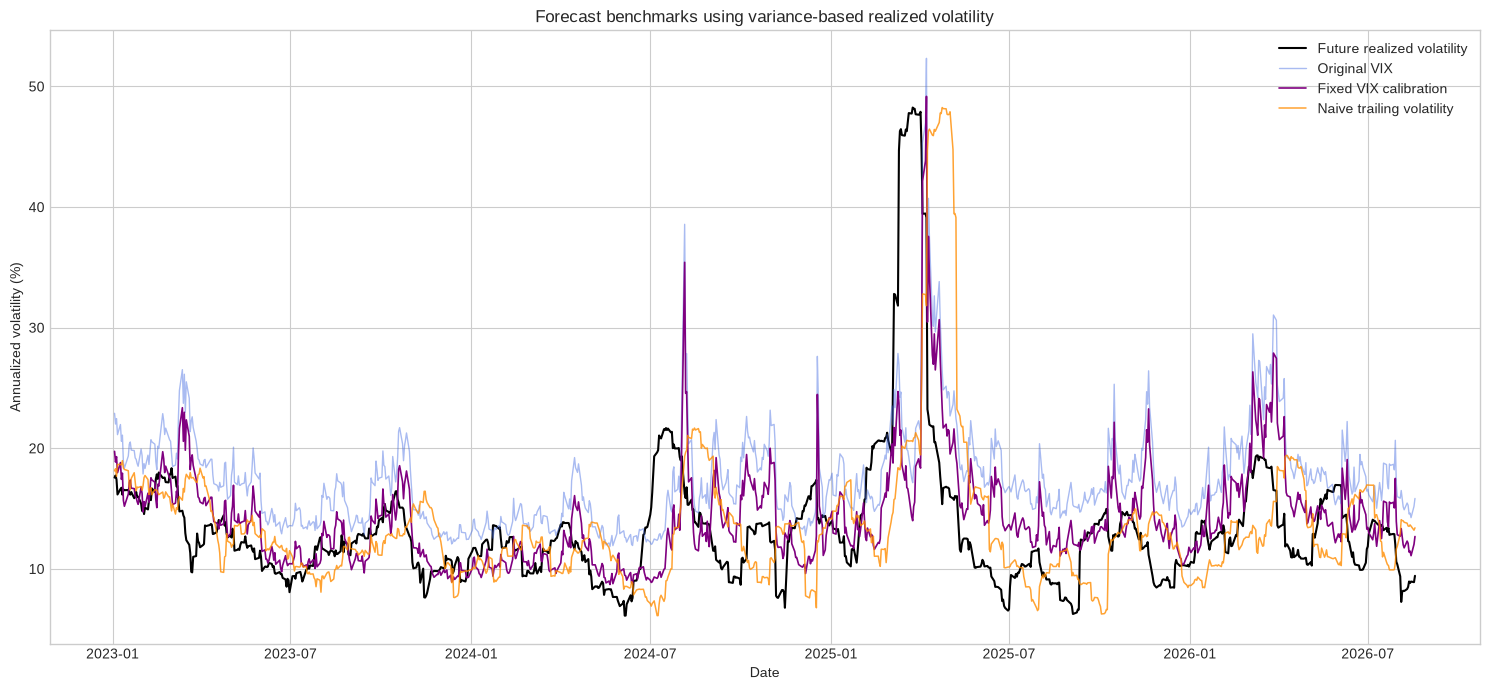

In [13]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    refined_test.index,
    refined_test["Future_realized_vol"],
    color="black",
    linewidth=1.5,
    label="Future realized volatility",
)
ax.plot(
    refined_test.index,
    refined_test["VIX_expected"],
    color="royalblue",
    alpha=0.45,
    linewidth=1.0,
    label="Original VIX",
)
ax.plot(
    refined_test.index,
    refined_test["Fixed_calibration"],
    color="purple",
    linewidth=1.2,
    label="Fixed VIX calibration",
)
ax.plot(
    refined_test.index,
    refined_test["Naive_trailing_vol"],
    color="darkorange",
    alpha=0.8,
    linewidth=1.1,
    label="Naive trailing volatility",
)

ax.set(
    title="Forecast benchmarks using variance-based realized volatility",
    xlabel="Date",
    ylabel="Annualized volatility (%)",
)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Supervised regression experiment

Ridge regression is deliberately used before a flexible tree model. It combines
several predictors while regularization limits coefficient instability.

All features are known at the forecast origin:

- current VIX level;
- recent VIX changes, rolling means, and rolling dispersion;
- trailing S&P 500 realized volatility;
- recent S&P 500 returns;
- current drawdown.

Hyperparameter selection uses `TimeSeriesSplit` with a **21-session gap**. Final
evaluation remains strictly out of sample from 2023 onward.

In [14]:
ml_data = data.copy()

ml_data["VIX_change_1"] = ml_data["VIX_expected"].diff(1)
ml_data["VIX_change_5"] = ml_data["VIX_expected"].diff(5)
ml_data["VIX_change_21"] = ml_data["VIX_expected"].diff(21)
ml_data["VIX_mean_5"] = ml_data["VIX_expected"].rolling(5).mean()
ml_data["VIX_mean_21"] = ml_data["VIX_expected"].rolling(21).mean()
ml_data["VIX_std_21"] = ml_data["VIX_expected"].rolling(21).std()

ml_data["Trailing_vol_21"] = ml_data["Trailing_realized_vol"]
ml_data["Trailing_vol_63"] = (
    np.sqrt(
        ml_data["SP500_log_return"]
        .pow(2)
        .rolling(63)
        .mean()
        * ANNUALIZATION
    )
    * 100
)

ml_data["SP500_return_5"] = ml_data["SP500"].pct_change(5)
ml_data["SP500_return_21"] = ml_data["SP500"].pct_change(21)
ml_data["SP500_drawdown_252"] = (
    ml_data["SP500"]
    / ml_data["SP500"].rolling(252).max()
    - 1
)

feature_columns = [
    "VIX_expected",
    "VIX_change_1",
    "VIX_change_5",
    "VIX_change_21",
    "VIX_mean_5",
    "VIX_mean_21",
    "VIX_std_21",
    "Trailing_vol_21",
    "Trailing_vol_63",
    "SP500_return_5",
    "SP500_return_21",
    "SP500_drawdown_252",
]
target_column = "Future_realized_vol"

model_data = (
    ml_data.loc[ANALYSIS_START:]
    .dropna(subset=feature_columns + [target_column])
    .copy()
)

train_candidates = model_data.loc[model_data.index < TEST_START]
train_ml = train_candidates.iloc[:-HORIZON].copy()
test_ml = model_data.loc[TEST_START:].copy()

X_train = train_ml[feature_columns]
y_train = train_ml[target_column]
X_test = test_ml[feature_columns]
y_test = test_ml[target_column]

print(
    f"ML training: {train_ml.index.min().date()} to "
    f"{train_ml.index.max().date()}"
)
print(
    f"ML testing:  {test_ml.index.min().date()} to "
    f"{test_ml.index.max().date()}"
)
print(f"Number of features: {len(feature_columns)}")

ML training: 2018-01-02 to 2022-11-30
ML testing:  2023-01-03 to 2026-08-18
Number of features: 12


In [15]:
ridge_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]
)

time_cv = TimeSeriesSplit(
    n_splits=5,
    gap=HORIZON,
)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"model__alpha": np.logspace(-3, 3, 25)},
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

ridge_prediction = np.clip(
    ridge_search.predict(X_test),
    a_min=0,
    a_max=None,
)
test_ml["Ridge_prediction"] = ridge_prediction

print(f"Best alpha: {ridge_search.best_params_['model__alpha']}")
print(f"Best cross-validated MAE: {-ridge_search.best_score_:.3f}")

Best alpha: 1000.0
Best cross-validated MAE: 6.834


## 11. Honest out-of-sample model comparison

The ML model must beat the original VIX, calibrated VIX, and naive trailing-volatility
forecast on exactly the same dates. Otherwise, its additional complexity is not
justified.

In [16]:
comparison = test_ml[[target_column]].copy()

comparison["Original VIX"] = data["VIX_expected"].reindex(
    comparison.index
)
comparison["Fixed VIX calibration"] = (
    comparison["Original VIX"] - refined_fixed_bias
)
comparison["Adaptive VIX calibration"] = refined_all[
    "Adaptive_calibration"
].reindex(comparison.index)
comparison["Naive trailing volatility"] = data[
    "Trailing_realized_vol"
].reindex(comparison.index)
comparison["Ridge regression"] = test_ml["Ridge_prediction"]

model_comparison_metrics = pd.concat(
    {
        column: evaluate_forecast(
            comparison[target_column],
            comparison[column],
        )
        for column in comparison.columns
        if column != target_column
    },
    axis=1,
)

display(model_comparison_metrics.round(3))

,Original VIX,Fixed VIX calibration,Adaptive VIX calibration,Naive trailing volatility,Ridge regression
Correlation,0.455,0.455,0.428,0.318,0.489
MAE,5.490,3.512,3.741,4.429,4.136
RMSE,6.857,5.646,5.866,7.082,5.799
Bias,3.977,0.823,0.563,0.172,2.331
Relative area gap,0.408,0.261,0.278,0.329,0.308
R2,-0.280,0.132,0.063,-0.365,0.085
Observations,909.000,909.000,909.000,909.000,909.000


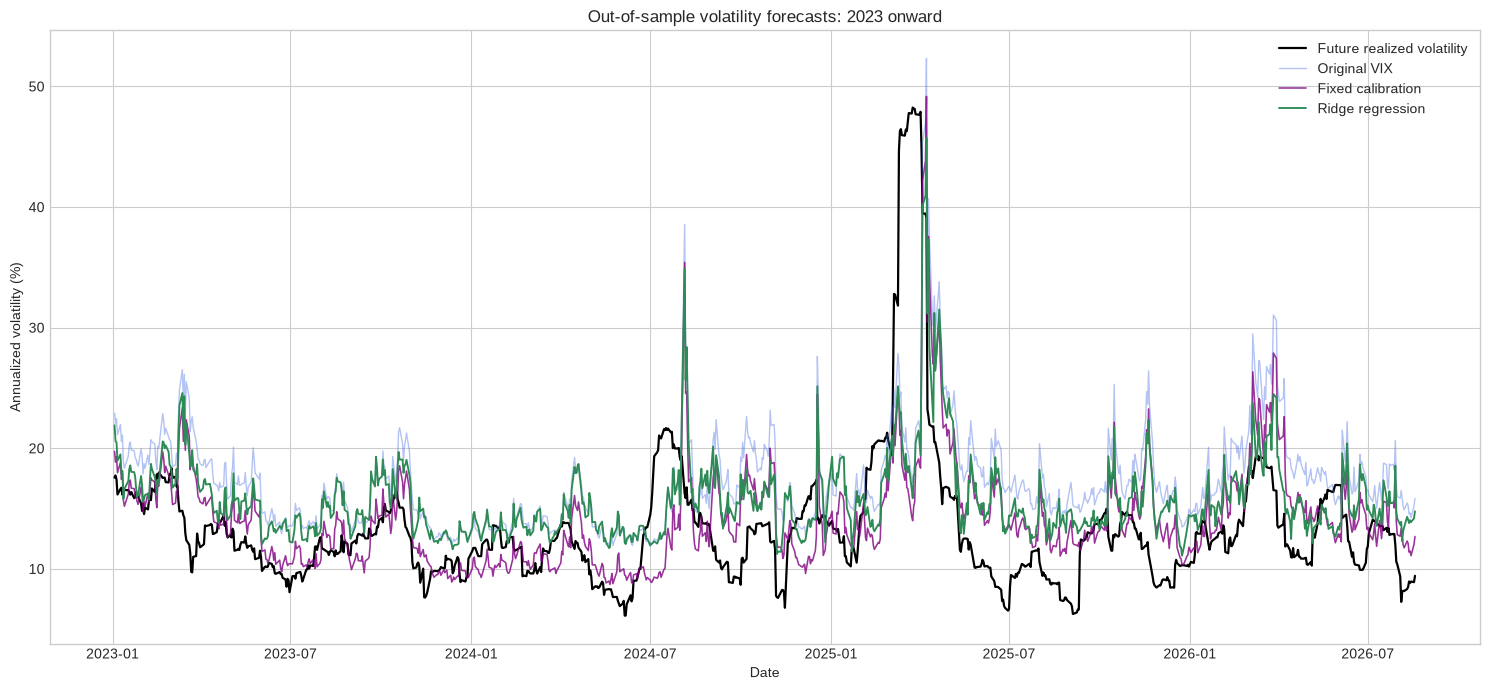

In [17]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    comparison.index,
    comparison[target_column],
    color="black",
    linewidth=1.6,
    label="Future realized volatility",
)
ax.plot(
    comparison.index,
    comparison["Original VIX"],
    color="royalblue",
    alpha=0.4,
    linewidth=1.0,
    label="Original VIX",
)
ax.plot(
    comparison.index,
    comparison["Fixed VIX calibration"],
    color="purple",
    alpha=0.8,
    linewidth=1.15,
    label="Fixed calibration",
)
ax.plot(
    comparison.index,
    comparison["Ridge regression"],
    color="seagreen",
    linewidth=1.35,
    label="Ridge regression",
)

ax.set(
    title="Out-of-sample volatility forecasts: 2023 onward",
    xlabel="Date",
    ylabel="Annualized volatility (%)",
)
ax.legend()
plt.tight_layout()
plt.show()

## 12. Model interpretation

Because the predictors are standardized inside the pipeline, coefficient magnitudes
are approximately comparable. They describe associations in the fitted linear model;
they do not establish causality.

In [18]:
ridge_model = ridge_search.best_estimator_.named_steps["model"]

coefficient_table = (
    pd.Series(
        ridge_model.coef_,
        index=feature_columns,
        name="Standardized coefficient",
    )
    .sort_values(key=np.abs, ascending=False)
    .to_frame()
)

display(coefficient_table)

,Standardized coefficient
VIX_std_21,1.149
VIX_change_5,1.148
VIX_expected,1.128
VIX_change_21,1.121
SP500_drawdown_252,-1.012
Trailing_vol_21,0.879
VIX_mean_5,0.848
SP500_return_5,-0.535
SP500_return_21,-0.473
Trailing_vol_63,0.401


## 13. Conclusions and limitations

After executing the notebook, answer four questions:

1. Does fixed calibration still reduce MAE under the variance-based target?
2. Does it beat the naive trailing-volatility forecast?
3. Does Ridge improve out-of-sample MAE, or does the one-parameter calibration
   generalize better?
4. Are improvements consistent across years and outside crisis periods?

### Limitations

- Forward 21-session targets overlap, so daily forecast errors are not statistically
  independent.
- The VIX is a risk-neutral implied-volatility measure and contains a variance risk
  premium; it is not designed to be an unbiased point forecast.
- High correlation measures co-movement, not calibration.
- Results depend on the target definition and evaluation period.
- Repeated tuning on the 2023-onward test set would invalidate it as an untouched test.

A strong result is not merely lower in-sample error. It is a method that beats the raw
VIX and a naive historical-volatility forecast on untouched future periods. The most
interesting result may remain the simplest one: a stable historical VIX bias can
improve future calibration without changing the shape of the index.

In [19]:
from sklearn.linear_model import LinearRegression

TARGET = "Future_realized_vol"

# 2004 evita misturar períodos com metodologias diferentes do VIX.
# Troque por "1990-01-01" se quiser usar absolutamente todo o histórico.
HISTORICAL_START = "2004-01-01"

historical_data = (
    data.loc[HISTORICAL_START:, ["VIX_expected", TARGET]]
    .dropna()
    .copy()
)

historical_data["VIX_error"] = (
    historical_data["VIX_expected"]
    - historical_data[TARGET]
)

print(
    historical_data.index.min().date(),
    "→",
    historical_data.index.max().date(),
)

display(historical_data.head())

2004-01-02 → 2026-08-18


,VIX_expected,Future_realized_vol,VIX_error
Date,,,
2004-01-02,18.220,10.856,7.364
2004-01-05,17.490,10.398,7.092
2004-01-06,16.730,10.407,6.323
2004-01-07,15.500,11.240,4.260
2004-01-08,15.610,11.144,4.466


In [20]:
def evaluate_historical_window(
    frame,
    test_start,
    train_years=5,
    test_years=1,
):
    test_start = pd.Timestamp(test_start)

    train_start = test_start - pd.DateOffset(years=train_years)
    test_end = test_start + pd.DateOffset(years=test_years)

    train_candidates = frame.loc[
        (frame.index >= train_start)
        & (frame.index < test_start)
    ].copy()

    # Remove as últimas 21 origens do treino porque seus alvos
    # usam retornos que avançariam para dentro do período de teste.
    if len(train_candidates) <= HORIZON:
        return None

    train = train_candidates.iloc[:-HORIZON].copy()

    test = frame.loc[
        (frame.index >= test_start)
        & (frame.index < test_end)
    ].copy()

    # Evita avaliar janelas com poucos dados.
    if len(train) < 252 or len(test) < 126:
        return None

    train_error = (
        train["VIX_expected"]
        - train[TARGET]
    )

    # Modelo 1: slope fixo em 1; aprende somente o bias.
    mean_bias = train_error.mean()

    # Modelo 2: também slope fixo em 1, mas otimiza MAE.
    median_bias = train_error.median()

    test["Mean_calibration"] = (
        test["VIX_expected"] - mean_bias
    )

    test["Median_calibration"] = (
        test["VIX_expected"] - median_bias
    )

    # Modelo 3: regressão simples.
    # Aprende tanto o intercepto quanto o slope.
    linear_model = LinearRegression()

    linear_model.fit(
        train[["VIX_expected"]],
        train[TARGET],
    )

    test["Linear_regression"] = np.clip(
        linear_model.predict(test[["VIX_expected"]]),
        a_min=0,
        a_max=None,
    )

    raw_metrics = evaluate_forecast(
        test[TARGET],
        test["VIX_expected"],
    )

    mean_metrics = evaluate_forecast(
        test[TARGET],
        test["Mean_calibration"],
    )

    median_metrics = evaluate_forecast(
        test[TARGET],
        test["Median_calibration"],
    )

    linear_metrics = evaluate_forecast(
        test[TARGET],
        test["Linear_regression"],
    )

    return {
        "Test_start": test.index.min(),
        "Test_end": test.index.max(),
        "Train_years": train_years,
        "Train_start": train.index.min(),
        "Train_end": train.index.max(),
        "Mean_bias": mean_bias,
        "Median_bias": median_bias,
        "OLS_intercept": linear_model.intercept_,
        "OLS_slope": linear_model.coef_[0],
        "Raw_MAE": raw_metrics["MAE"],
        "Mean_calibration_MAE": mean_metrics["MAE"],
        "Median_calibration_MAE": median_metrics["MAE"],
        "OLS_MAE": linear_metrics["MAE"],
        "Raw_bias": raw_metrics["Bias"],
        "Mean_calibration_bias": mean_metrics["Bias"],
        "Median_calibration_bias": median_metrics["Bias"],
        "OLS_bias": linear_metrics["Bias"],
        "Observations": len(test),
    }

In [21]:
TRAIN_LENGTHS = [2, 3, 5, 8, 10]
TEST_YEARS = 1

historical_results = []

for train_years in TRAIN_LENGTHS:
    first_possible_start = (
        historical_data.index.min()
        + pd.DateOffset(years=train_years)
    )

    last_possible_start = (
        historical_data.index.max()
        - pd.DateOffset(years=TEST_YEARS)
    )

    # Uma nova janela por mês.
    test_starts = pd.date_range(
        start=first_possible_start,
        end=last_possible_start,
        freq="MS",
    )

    for test_start in test_starts:
        result = evaluate_historical_window(
            frame=historical_data,
            test_start=test_start,
            train_years=train_years,
            test_years=TEST_YEARS,
        )

        if result is not None:
            historical_results.append(result)

historical_results = pd.DataFrame(historical_results)

historical_results["Mean_MAE_improvement"] = (
    1
    - historical_results["Mean_calibration_MAE"]
    / historical_results["Raw_MAE"]
)

historical_results["Median_MAE_improvement"] = (
    1
    - historical_results["Median_calibration_MAE"]
    / historical_results["Raw_MAE"]
)

historical_results["OLS_MAE_improvement"] = (
    1
    - historical_results["OLS_MAE"]
    / historical_results["Raw_MAE"]
)

print(f"Historical windows evaluated: {len(historical_results):,}")

display(historical_results.head())

Historical windows evaluated: 959


,Test_start,Test_end,Train_years,Train_start,Train_end,Mean_bias,Median_bias,OLS_intercept,OLS_slope,Raw_MAE,...,Median_calibration_MAE,OLS_MAE,Raw_bias,Mean_calibration_bias,Median_calibration_bias,OLS_bias,Observations,Mean_MAE_improvement,Median_MAE_improvement,OLS_MAE_improvement
0,2006-02-01,2007-01-31,2,2004-02-02,2005-12-29,3.549,3.404,5.510,0.356,3.637,...,1.666,2.191,3.356,-0.193,-0.048,0.670,251,0.546,0.542,0.398
1,2006-03-01,2007-02-28,2,2004-03-01,2006-01-27,3.476,3.389,5.536,0.352,3.790,...,2.290,2.609,2.661,-0.815,-0.729,0.015,251,0.396,0.396,0.312
2,2006-04-03,2007-03-30,2,2004-04-01,2006-03-02,3.453,3.400,5.546,0.341,3.924,...,2.388,2.615,2.790,-0.663,-0.610,-0.188,250,0.392,0.391,0.334
3,2006-05-01,2007-04-30,2,2004-05-03,2006-03-29,3.446,3.400,5.563,0.332,4.078,...,2.331,2.600,2.956,-0.490,-0.444,-0.174,251,0.430,0.428,0.363
4,2006-06-01,2007-05-31,2,2004-06-01,2006-05-01,3.226,3.258,5.053,0.375,4.076,...,2.226,2.396,3.110,-0.116,-0.149,0.087,251,0.452,0.454,0.412


In [22]:
historical_summary = (
    historical_results
    .groupby("Train_years")
    .agg(
        Windows=("Test_start", "size"),

        Median_learned_bias=("Mean_bias", "median"),
        Bias_p10=("Mean_bias", lambda x: x.quantile(0.10)),
        Bias_p90=("Mean_bias", lambda x: x.quantile(0.90)),

        Median_OLS_intercept=("OLS_intercept", "median"),
        Median_OLS_slope=("OLS_slope", "median"),

        Median_mean_gain=(
            "Mean_MAE_improvement",
            "median",
        ),
        Mean_calibration_win_rate=(
            "Mean_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),

        Median_median_gain=(
            "Median_MAE_improvement",
            "median",
        ),
        Median_calibration_win_rate=(
            "Median_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),

        Median_OLS_gain=(
            "OLS_MAE_improvement",
            "median",
        ),
        OLS_win_rate=(
            "OLS_MAE_improvement",
            lambda x: (x > 0).mean(),
        ),
    )
)

percentage_columns = [
    "Median_mean_gain",
    "Mean_calibration_win_rate",
    "Median_median_gain",
    "Median_calibration_win_rate",
    "Median_OLS_gain",
    "OLS_win_rate",
]

historical_summary[percentage_columns] *= 100

display(historical_summary.round(3))

,Windows,Median_learned_bias,Bias_p10,Bias_p90,Median_OLS_intercept,Median_OLS_slope,Median_mean_gain,Mean_calibration_win_rate,Median_median_gain,Median_calibration_win_rate,Median_OLS_gain,OLS_win_rate
Train_years,,,,,,,,,,,,
2,235,3.352,2.079,5.057,0.792,0.795,23.772,92.766,26.670,93.617,22.648,87.234
3,223,3.317,1.860,4.972,-0.298,0.824,23.348,96.861,26.066,94.619,24.662,89.238
5,199,3.475,2.572,4.287,-0.230,0.838,26.336,100.000,27.991,97.487,27.755,98.492
8,163,3.465,3.219,3.965,-0.725,0.853,29.452,100.000,30.123,97.546,29.975,98.160
10,139,3.417,3.281,3.719,-0.574,0.843,28.428,100.000,28.347,97.842,29.091,97.842


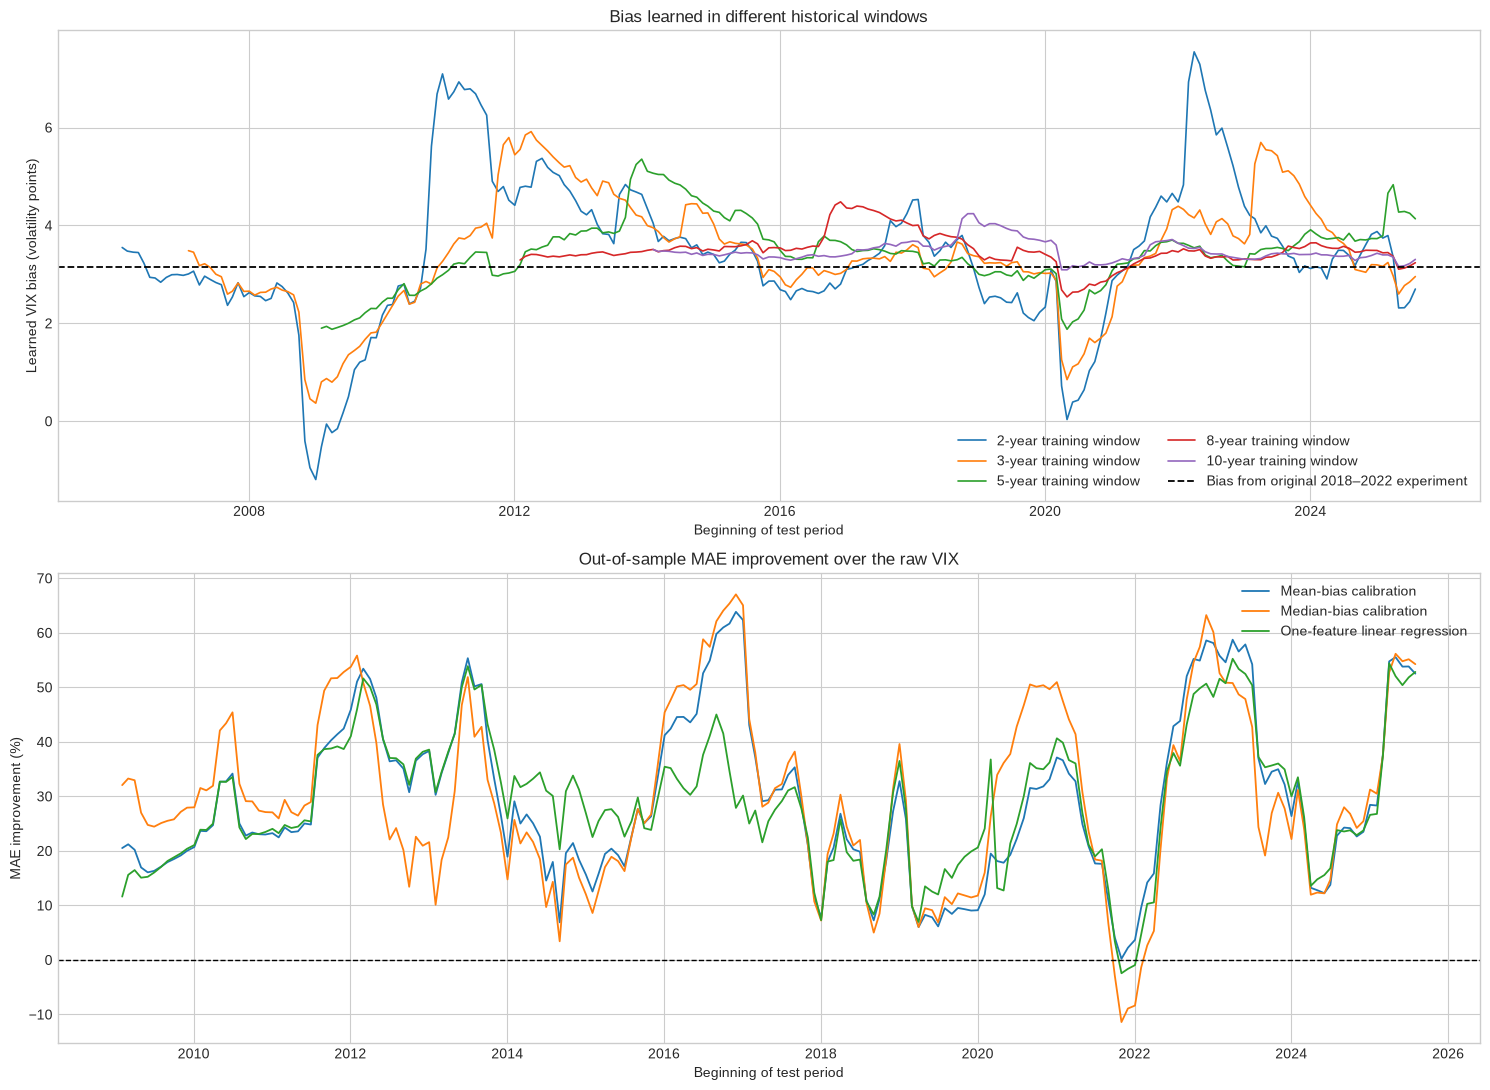

In [23]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 11),
    sharex=False,
)

# Evolução do bias aprendido
for train_years in TRAIN_LENGTHS:
    subset = historical_results[
        historical_results["Train_years"] == train_years
    ]

    axes[0].plot(
        subset["Test_start"],
        subset["Mean_bias"],
        linewidth=1.2,
        label=f"{train_years}-year training window",
    )

axes[0].axhline(
    3.155,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Bias from original 2018–2022 experiment",
)

axes[0].set(
    title="Bias learned in different historical windows",
    xlabel="Beginning of test period",
    ylabel="Learned VIX bias (volatility points)",
)

axes[0].legend(ncol=2)


# Comparação concentrada nas janelas de treino de 5 anos
five_year_results = historical_results[
    historical_results["Train_years"] == 5
]

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["Mean_MAE_improvement"],
    label="Mean-bias calibration",
    linewidth=1.3,
)

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["Median_MAE_improvement"],
    label="Median-bias calibration",
    linewidth=1.3,
)

axes[1].plot(
    five_year_results["Test_start"],
    100 * five_year_results["OLS_MAE_improvement"],
    label="One-feature linear regression",
    linewidth=1.3,
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set(
    title="Out-of-sample MAE improvement over the raw VIX",
    xlabel="Beginning of test period",
    ylabel="MAE improvement (%)",
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
annual_results = historical_results[
    (historical_results["Train_years"] == 5)
    & (historical_results["Test_start"].dt.month == 1)
].copy()

annual_results["Test_year"] = (
    annual_results["Test_start"].dt.year
)

annual_table = annual_results[
    [
        "Test_year",
        "Mean_bias",
        "Median_bias",
        "OLS_intercept",
        "OLS_slope",
        "Raw_MAE",
        "Mean_calibration_MAE",
        "Median_calibration_MAE",
        "OLS_MAE",
        "Mean_MAE_improvement",
        "Median_MAE_improvement",
        "OLS_MAE_improvement",
    ]
].set_index("Test_year")

improvement_columns = [
    "Mean_MAE_improvement",
    "Median_MAE_improvement",
    "OLS_MAE_improvement",
]

annual_table[improvement_columns] *= 100

display(annual_table.round(3))

,Mean_bias,Median_bias,OLS_intercept,OLS_slope,Raw_MAE,Mean_calibration_MAE,Median_calibration_MAE,OLS_MAE,Mean_MAE_improvement,Median_MAE_improvement,OLS_MAE_improvement
Test_year,,,,,,,,,,,
2010,2.435,3.400,-2.023,0.981,7.965,6.315,5.736,6.287,20.713,27.991,21.071
2011,3.084,4.240,-2.186,0.962,7.404,5.682,5.400,5.623,23.255,27.068,24.045
2012,3.062,4.935,-1.275,0.931,5.249,2.840,2.427,3.096,45.900,53.756,41.026
2013,3.884,5.735,-3.541,0.987,3.805,2.346,2.983,2.337,38.337,21.604,38.575
2014,5.107,5.557,-1.451,0.835,4.230,3.430,3.606,3.132,18.928,14.767,25.955
2015,4.293,4.798,0.320,0.752,4.913,4.143,4.321,3.590,15.666,12.044,26.932
2016,3.487,4.068,1.041,0.740,5.164,3.035,2.819,3.334,41.217,45.413,35.435
2017,3.602,4.095,4.023,0.517,4.338,1.634,1.516,3.030,62.337,65.050,30.151
2018,3.471,4.157,0.712,0.711,6.193,5.714,5.746,5.742,7.748,7.225,7.288
